In [1]:
import pygbif 

In [2]:
test_name = "Vespa velutina"
pygbif.species.name_backbone(test_name)

{'usage': {'key': '1311477',
  'name': 'Vespa velutina Lepeletier, 1836',
  'canonicalName': 'Vespa velutina',
  'authorship': 'Lepeletier, 1836',
  'rank': 'SPECIES',
  'code': 'ZOOLOGICAL',
  'status': 'ACCEPTED',
  'genericName': 'Vespa',
  'specificEpithet': 'velutina',
  'type': 'SCIENTIFIC',
  'formattedName': '<i>Vespa</i> <i>velutina</i> Lepeletier, 1836'},
 'classification': [{'key': '1', 'name': 'Animalia', 'rank': 'KINGDOM'},
  {'key': '54', 'name': 'Arthropoda', 'rank': 'PHYLUM'},
  {'key': '216', 'name': 'Insecta', 'rank': 'CLASS'},
  {'key': '1457', 'name': 'Hymenoptera', 'rank': 'ORDER'},
  {'key': '4490', 'name': 'Vespidae', 'rank': 'FAMILY'},
  {'key': '1311334', 'name': 'Vespa', 'rank': 'GENUS'},
  {'key': '1311477', 'name': 'Vespa velutina', 'rank': 'SPECIES'}],
 'diagnostics': {'matchType': 'EXACT',
  'confidence': 99,
  'timeTaken': 3,
  'timings': {'nameNRank': 0,
   'sciNameMatch': 3,
   'nameParse': 0,
   'luceneMatch': 3}},
 'synonym': False}

In [3]:
# The unique dataset UUID for the Catalogue of Life in GBIF
COL_DATASET_KEY = "7ddf754f-d193-4cc9-b351-99906754a03b"

# Search for the name within the CoL dataset
search_results = pygbif.species.name_lookup(
    q="Vespa velutina", 
    datasetKey=COL_DATASET_KEY,
    limit=5
)

# Parse and print the results
if search_results and 'results' in search_results:
    for record in search_results['results']:
        print(f"Scientific Name: {record.get('scientificName')}")
        print(f"GBIF Taxon Key:  {record.get('key')}")       # Internal GBIF reference
        print(f"Official CoL ID: {record.get('taxonID')}")   # Native Catalogue of Life ID
        print(f"Rank:           {record.get('rank')}")
        print(f"Status:         {record.get('status')}")
        print("-" * 40)
else:
    print("No matches found.")

Scientific Name: Vespa velutina Lepeletier, 1836
GBIF Taxon Key:  296612081
Official CoL ID: 7G3C6
Rank:           SPECIES
Status:         None
----------------------------------------
Scientific Name: Vespa velutina f. auraria
GBIF Taxon Key:  314459349
Official CoL ID: FQM3Q
Rank:           FORM
Status:         None
----------------------------------------
Scientific Name: Vespa velutina f. floresiana
GBIF Taxon Key:  314459344
Official CoL ID: TPRYH
Rank:           FORM
Status:         None
----------------------------------------
Scientific Name: Vespa velutina f. variana
GBIF Taxon Key:  314459341
Official CoL ID: TPRZB
Rank:           FORM
Status:         None
----------------------------------------
Scientific Name: Vespa velutina f. timorensis
GBIF Taxon Key:  314459342
Official CoL ID: TPRZ5
Rank:           FORM
Status:         None
----------------------------------------


In [4]:
search_results = pygbif.species.name_lookup(
    q="Vespa velutina", 
    datasetKey=COL_DATASET_KEY,
    status="ACCEPTED",  # Ignores synonyms and doubtful names
    limit=5
)
search_results

{'offset': 0,
 'limit': 5,
 'endOfRecords': False,
 'count': 23,
 'results': [{'key': 296612081,
   'datasetKey': '7ddf754f-d193-4cc9-b351-99906754a03b',
   'nubKey': 1311477,
   'parentKey': 296612032,
   'parent': 'Vespa',
   'kingdom': 'Animalia',
   'phylum': 'Arthropoda',
   'order': 'Hymenoptera',
   'family': 'Vespidae',
   'genus': 'Vespa',
   'species': 'Vespa velutina',
   'kingdomKey': 296374190,
   'phylumKey': 296374886,
   'classKey': 296434567,
   'orderKey': 296455055,
   'familyKey': 307388955,
   'genusKey': 296612032,
   'speciesKey': 296612081,
   'scientificName': 'Vespa velutina Lepeletier, 1836',
   'canonicalName': 'Vespa velutina',
   'authorship': 'Lepeletier, 1836',
   'publishedIn': "Lepeletier, A. L. M. (1836) Histoire Naturelle des Insectes. Hymenopteres. Vol. 1. Roret's Suites a Buffon, Paris, 547 pp.",
   'nameType': 'SCIENTIFIC',
   'taxonomicStatus': 'ACCEPTED',
   'rank': 'SPECIES',
   'origin': 'SOURCE',
   'numDescendants': 0,
   'numOccurrences': 0

In [7]:
from pygbif import species

COL_DATASET_KEY = "7ddf754f-d193-4cc9-b351-99906754a03b"
target_col_id = "7G3C6"

print(f"Translating CoL ID '{target_col_id}'...")

# Use name_usage with sourceId to fetch the exact record by its native ID
lookup_result = species.name_usage(
    datasetKey=COL_DATASET_KEY,
    sourceId=target_col_id
)

# name_usage returns the list of results directly inside the 'results' key
if lookup_result and lookup_result.get('results'):
    taxon_record = lookup_result['results'][0]
    gbif_backbone_key = taxon_record.get('nubKey')
    scientific_name = taxon_record.get('scientificName')
    
    if gbif_backbone_key:
        print(f"→ Successfully mapped '{scientific_name}' to GBIF Key: {gbif_backbone_key}")
        # Proceed to occurrences.search here...
    else:
        print("⚠️ The CoL ID exists, but it does not have a mapped backbone key in GBIF.")
else:
    print("❌ Could not find that CoL ID within the Catalogue of Life dataset.")

Translating CoL ID '7G3C6'...
→ Successfully mapped 'Vespa velutina Lepeletier, 1836' to GBIF Key: 1311477


In [12]:
from pygbif import occurrences

# Define your bounding box coordinates
min_lat, max_lat = 50.621588, 51.566827    # e.g., roughly France
min_lon, max_lon = 2.466355, 6.099105

# Search using coordinate ranges
results = occurrences.search(key = 1311477,
    decimalLatitude=f"{min_lat},{max_lat}",
    decimalLongitude=f"{min_lon},{max_lon}",
    hasCoordinate=True,  # Ensures you only get records with mapped locations
)

print(f"Total records found in box: {results.get('count')}")

Total records found in box: 65768210


In [13]:
results = occurrences.search(key = "7G3C6",
    decimalLatitude=f"{min_lat},{max_lat}",
    decimalLongitude=f"{min_lon},{max_lon}",
    hasCoordinate=True,  # Ensures you only get records with mapped locations
)

print(f"Total records found in box: {results.get('count')}")

Total records found in box: 65768210


# Converting to bmd cube

In [1]:
import pandas as pd
from bmc.datasource.gbif import harmonisation
from bmc.engine import spatial

spatial_engine = spatial.spatial_engine()
bbox = [6.365693, 50.50134, 6.472005, 50.650193]
gdf = pd.read_csv("0002756-260623161305970.csv", sep="\t")
gdf["geometry"] =  gdf["eeacellcode"].apply(harmonisation.parse_to_polygon)
gdf

,scientificname,year,month,day,countrycode,eeacellcode,occurrences,distinctobservers,geometry
0,"Limnephilus Leach, 1815",2024,11,2,DE,250mE406950N306375,1,1,"POLYGON ((4069750 3063750, 4069750 3064000, 40..."
1,Lycaenidae,2020,6,20,DE,250mE406450N305425,1,1,"POLYGON ((4064750 3054250, 4064750 3054500, 40..."
2,"Tischeria ekebladella (Bjerkander, 1795)",2024,9,18,DE,250mE407125N306375,1,1,"POLYGON ((4071500 3063750, 4071500 3064000, 40..."
3,"Potamophylax Wallengren, 1891",2021,8,22,DE,250mE406350N305700,1,1,"POLYGON ((4063750 3057000, 4063750 3057250, 40..."
4,"Cabera exanthemata (Scopoli, 1763)",2023,6,4,DE,250mE406525N305500,1,1,"POLYGON ((4065500 3055000, 4065500 3055250, 40..."
...,...,...,...,...,...,...,...,...,...
1590,"Vespa Linnaeus, 1758",2020,5,29,DE,250mE406750N305475,1,1,"POLYGON ((4067750 3054750, 4067750 3055000, 40..."
1591,"Acronicta tridens (Denis & Schiffermüller) , 1775",2022,7,18,DE,250mE406350N305700,1,1,"POLYGON ((4063750 3057000, 4063750 3057250, 40..."
1592,Sericostomatidae,2021,9,16,DE,250mE406350N305675,1,1,"POLYGON ((4063750 3056750, 4063750 3057000, 40..."
1593,"Halesus Stephens, 1836",2021,9,16,DE,250mE406350N305725,1,1,"POLYGON ((4063750 3057250, 4063750 3057500, 40..."


In [7]:
import pandas as pd
import xarray as xr
import xvec
from xvec import GeometryIndex # We import the index class directly

from bmc.datasource.gbif import harmonisation
from bmc.engine import spatial

# --- Your initial loading code ---
spatial_engine = spatial.spatial_engine()
bbox = [6.365693, 50.50134, 6.472005, 50.650193]
gdf = pd.read_csv("0002756-260623161305970.csv", sep="\t")

# Parse geometries (assuming this returns standard Shapely Polygons)
gdf["geometry"] = gdf["eeacellcode"].apply(harmonisation.parse_to_polygon)

# --- 1. Standardize the Temporal Dimension ---
gdf['year_month'] = (
    gdf['year'].astype(str) + '-' + 
    gdf['month'].astype(str).str.zfill(2)
)

# --- 2. Sum Up Duplicates (Flat DataFrame) ---
aggregated_df = (
    gdf.groupby(['scientificname', 'year_month', 'geometry'], as_index=False, sort=False)
    ['occurrences'].sum()
)

# --- 3. Convert directly to a 1D xarray Dataset ---
vector_ds = xr.Dataset.from_dataframe(aggregated_df)

# --- 4. Set the coordinates ---
vector_ds = vector_ds.set_coords(['scientificname', 'year_month', 'geometry'])

# --- 5. The Fix: Native Xarray Index Assignment ---
# We bypass the xvec accessor and attach the GeometryIndex directly.
vector_ds = vector_ds.set_xindex("geometry", GeometryIndex, crs="EPSG:3035")

print(vector_ds)

<xarray.Dataset> Size: 117kB
Dimensions:         (index: 1507)
Coordinates:
    scientificname  (index) str 58kB <class 'xarray.core.extension_array.Pand...
    year_month      (index) str 23kB <class 'xarray.core.extension_array.Pand...
  * geometry        (index) object 12kB POLYGON ((4069750 3063750, 4069750 30...
  * index           (index) int64 12kB 0 1 2 3 4 5 ... 1502 1503 1504 1505 1506
Data variables:
    occurrences     (index) int64 12kB 1 1 1 3 1 3 1 3 1 1 ... 1 1 1 1 1 1 1 1 1
Indexes:
    geometry  GeometryIndex (crs=EPSG:3035)


In [11]:
vector_ds

<xarray.Dataset> Size: 117kB
Dimensions:         (index: 1507)
Coordinates:
    scientificname  (index) str 58kB <class 'xarray.core.extension_array.Pand...
    year_month      (index) str 23kB <class 'xarray.core.extension_array.Pand...
  * geometry        (index) object 12kB POLYGON ((4069750 3063750, 4069750 30...
  * index           (index) int64 12kB 0 1 2 3 4 5 ... 1502 1503 1504 1505 1506
Data variables:
    occurrences     (index) int64 12kB 1 1 1 3 1 3 1 3 1 1 ... 1 1 1 1 1 1 1 1 1
Indexes:
    geometry  GeometryIndex (crs=EPSG:3035)

In [6]:
import geopandas as gpd
from shapely.geometry import box
import logging
from typing import Tuple, Optional

def sanitize_gdf_by_bbox(
    gdf: gpd.GeoDataFrame, 
    sample_bbox: Tuple[float, float, float, float], 
    bbox_crs: str = "EPSG:4326",
    logger: Optional[logging.Logger] = None
) -> gpd.GeoDataFrame:
    """
    Filters out any rows in a GeoDataFrame whose geometries do not intersect 
    the intended sampling bounding box, safely accounting for CRS mismatches.
    
    Parameters:
    -----------
    gdf : geopandas.GeoDataFrame
        The input spatial dataframe to sanitize (e.g., your loaded GBIF cube data).
    sample_bbox : tuple of float
        The bounding box limits defined as (minx, miny, maxx, maxy).
    bbox_crs : str, optional
        The Coordinate Reference System of the input sample_bbox coordinates. 
        Default is "EPSG:4326" (WGS84 decimal degrees).
    logger : logging.Logger, optional
        An optional logger instance to track how many rows were dropped.
        
    Returns:
    --------
    geopandas.GeoDataFrame
        A cleaned copy of the input GeoDataFrame containing only the cells 
        that validly sit within or touch the sampling bounding box.
    """
    if gdf.empty:
        return gdf.copy()
        
    # 1. Represent the bounding box as a formal spatial geometry
    bbox_poly = box(*sample_bbox)
    bbox_gdf = gpd.GeoDataFrame(geometry=[bbox_poly], crs=bbox_crs)
    
    # 2. Match the bounding box CRS to the data's native projection
    # (Reprojecting the 1-row box is computationally instant compared to reprojecting the entire gdf)
    if gdf.crs != bbox_gdf.crs:
        if logger:
            logger.info(f"🔄 Aligning sampling box CRS from {bbox_crs} to match data CRS ({gdf.crs})...")
        bbox_aligned = bbox_gdf.to_crs(gdf.crs)
    else:
        bbox_aligned = bbox_gdf.copy()
        
    # Extract the reprojected polygon shape for the mask evaluation
    target_bbox_shape = bbox_aligned.geometry.values[0]
    
    # 3. Create a spatial mask using an intersection predicate
    # This evaluates whether any part of the cell geometry touches or falls inside the box
    spatial_mask = gdf.geometry.intersects(target_bbox_shape)
    
    # 4. Filter the data
    gdf_cleaned = gdf[spatial_mask].copy()
    
    # 5. Log execution metrics for validation tracking
    dropped_count = len(gdf) - len(gdf_cleaned)
    if logger:
        logger.info(
            f"🧹 Sanitization Complete: Retained {len(gdf_cleaned)} cells. "
            f"Filtered out {dropped_count} outlier cells that drifted outside the sampling footprint."
        )
    else:
        print(f"🧹 Sanitized: Kept {len(gdf_cleaned)} rows, dropped {dropped_count} outliers.")
        
    return gdf_cleaned

In [7]:
gdf_sanitized = sanitize_gdf_by_bbox(
    gdf=gbif_table, 
    sample_bbox=bbox, 
    bbox_crs="EPSG:4326"
)
gdf_sanitized

AttributeError: 'DataFrame' object has no attribute 'crs'

C:\Users\niels\AppData\Local\Temp\ipykernel_33208\3182023303.py:29: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  zeros.plot(ax=ax, facecolor="none", edgecolor="#F0F0F0", linewidth=0.4)


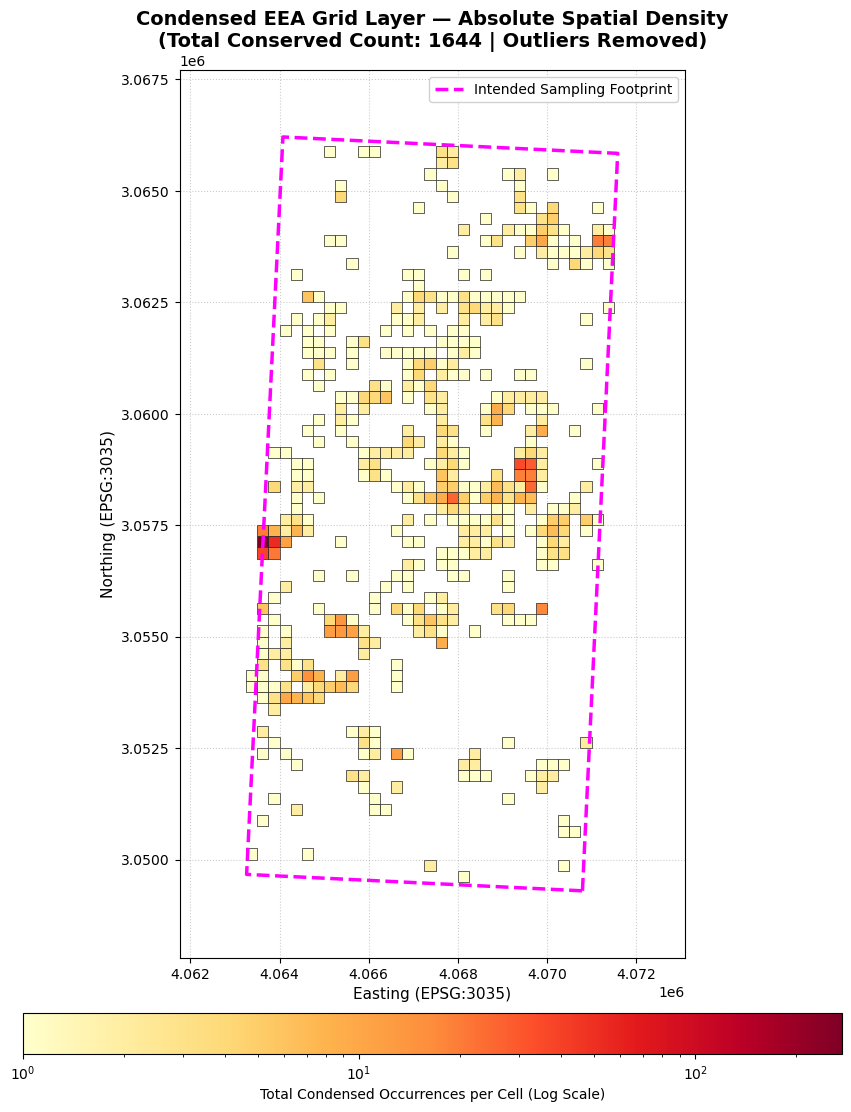

In [164]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
import geopandas as gpd
from shapely.geometry import box

# 1. Condense the data across species and years
# We group by the cell geometry and sum up all occurrences to collapse the table spatially
eea_condensed_counts = (
    gdf_sanitized.groupby("geometry")["occurrences"]
    .sum()
    .reset_index()
)
eea_condensed_gdf = gpd.GeoDataFrame(eea_condensed_counts, geometry="geometry", crs=gdf_sanitized.crs)

# 2. Set up the original WGS84 sampling footprint boundary for overlay
bbox = [6.365693, 50.50134, 6.472005, 50.650193]
bbox_poly = box(*bbox)
bbox_gdf = gpd.GeoDataFrame(geometry=[bbox_poly], crs="EPSG:4326").to_crs(gdf_sanitized.crs)

# 3. Initialize a single-frame plot
fig, ax = plt.subplots(figsize=(12, 12))

# Split into active cells vs empty cells to keep the background grid clean
zeros = eea_condensed_gdf[eea_condensed_gdf["occurrences"] == 0]
active_cells = eea_condensed_gdf[eea_condensed_gdf["occurrences"] > 0]

# Plot cells with 0 records as subtle light-gray outlines
zeros.plot(ax=ax, facecolor="none", edgecolor="#F0F0F0", linewidth=0.4)

# Plot absolute occurrence density per cell using a Logarithmic scale 
# (This ensures low count areas remain visible alongside massive hotspots)
if not active_cells.empty:
    active_cells.plot(
        ax=ax,
        column="occurrences",
        cmap="YlOrRd",
        linewidth=0.5,
        edgecolor="#222222",
        norm=LogNorm(vmin=1, vmax=eea_condensed_gdf["occurrences"].max()),
        legend=True,
        legend_kwds={
            "label": "Total Condensed Occurrences per Cell (Log Scale)", 
            "orientation": "horizontal", 
            "pad": 0.05,
            "shrink": 0.7
        }
    )

# Superimpose the strict sampling perimeter boundary line
bbox_gdf.plot(
    ax=ax, 
    facecolor="none", 
    edgecolor="magenta", 
    linewidth=2.5, 
    linestyle="--", 
    zorder=5
)

# 4. Set plot view limits tightly around the sampling box with a small buffer
# Adds 1,500 meters of margins so perimeter cells aren't clipped by the image edges
pad = 1500
b = bbox_gdf.total_bounds
ax.set_xlim(b[0] - pad, b[2] + pad)
ax.set_ylim(b[1] - pad, b[3] + pad)

# 5. Formatting and Titles
ax.set_title(
    f"Condensed EEA Grid Layer — Absolute Spatial Density\n"
    f"(Total Conserved Count: {eea_condensed_gdf['occurrences'].sum()} | Outliers Removed)", 
    fontsize=14, 
    fontweight="bold"
)
ax.set_xlabel("Easting (EPSG:3035)", fontsize=11)
ax.set_ylabel("Northing (EPSG:3035)", fontsize=11)
ax.grid(True, linestyle=":", alpha=0.4, color="gray")

# Add an explicit legend indicator for the boundary line
legend_elements = [
    Line2D([0], [0], color="magenta", lw=2.5, linestyle="--", label="Intended Sampling Footprint")
]
ax.legend(handles=legend_elements, loc="upper right", framealpha=0.9)

plt.tight_layout()
plt.show()

In [156]:
import math
import numpy as np
import xarray as xr
import rioxarray
from pyproj import CRS

def create_aligned_raster_template(sample_bbox, grid_name, registry=spatial_engine.GRID_REGISTRY):
    """
    Takes a bounding box and generates an empty xarray DataArray that perfectly 
    aligns with the specified master grid from the registry. 
    
    Bakes in the CRS, grid registry key, resolution, and native spatial units.
    """
    master = registry[grid_name]
    res = master["resolution"]
    master_minx, master_miny, master_maxx, master_maxy = master["bounds"]
    
    # sample_bbox is (minx, miny, maxx, maxy)
    s_minx, s_miny, s_maxx, s_maxy = sample_bbox
    
    # 1. Snap strictly to the Master Grid intervals
    aligned_minx = master_minx + math.floor((s_minx - master_minx) / res) * res
    aligned_miny = master_miny + math.floor((s_miny - master_miny) / res) * res
    aligned_maxx = master_minx + math.ceil((s_maxx - master_minx) / res) * res
    aligned_maxy = master_miny + math.ceil((s_maxy - master_miny) / res) * res
    
    # 2. Calculate integer dimensions safely
    width = int(round((aligned_maxx - aligned_minx) / res))
    height = int(round((aligned_maxy - aligned_miny) / res))
    
    # 3. Generate spatial coordinates (Pixel Centers)
    x_coords = aligned_minx + (np.arange(width) + 0.5) * res
    y_coords = aligned_maxy - (np.arange(height) + 0.5) * res
    
    # 4. Dynamically determine spatial units from the CRS
    crs_obj = CRS.from_string(master["crs"])
    spatial_unit = "degrees" if crs_obj.is_geographic else "meters"
    
    # 5. Create the DataArray template with robust metadata attributes
    template = xr.DataArray(
        data=np.zeros((height, width), dtype=np.int32), 
        coords={"y": y_coords, "x": x_coords},
        dims=("y", "x"),
        attrs={
            "grid_registry_key": grid_name,
            "res": res,
            "spatial_unit": spatial_unit
        }
    )
    
    # 6. Inject CF-compliant spatial topology FIRST (Creates 'spatial_ref')
    template = template.rio.write_crs(master["crs"])
    
    # 7. MANUALLY FORCE IT IN LAST: Assign the text attribute *after* rioxarray finishes its cleanup
    template.attrs["crs"] = str(master["crs"])
    
    return template, (aligned_minx, aligned_miny, aligned_maxx, aligned_maxy)

In [157]:
wsg84_template, _ = create_aligned_raster_template(bbox, "Global_WGS84_7_5sec", registry=spatial_engine.GRID_REGISTRY)

eea_bbox = transform_bbox(bbox, "EPSG:4326", "EPSG:3035")
eea_template, _ = create_aligned_raster_template(eea_bbox, "EEA_250m", registry=spatial_engine.GRID_REGISTRY)

gea_bbox = transform_bbox(bbox, "EPSG:4326", "EPSG:6933")
gea_template, _ = create_aligned_raster_template(gea_bbox, "Global_EqualArea_250m", registry=spatial_engine.GRID_REGISTRY)

In [158]:
wsg84_template

<xarray.DataArray (y: 73, x: 52)> Size: 15kB
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(73, 52), dtype=int32)
Coordinates:
  * y            (y) float64 584B 50.65 50.65 50.65 50.64 ... 50.51 50.5 50.5
  * x            (x) float64 416B 6.366 6.368 6.37 6.372 ... 6.468 6.47 6.472
    spatial_ref  int64 8B 0
Attributes:
    grid_registry_key:  Global_WGS84_7_5sec
    res:                0.0020833333333333333
    spatial_unit:       degrees
    crs:                EPSG:4326

In [159]:
eea_template

<xarray.DataArray (y: 66, x: 34)> Size: 9kB
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(66, 34), dtype=int32)
Coordinates:
  * y            (y) float64 528B 3.066e+06 3.066e+06 ... 3.05e+06 3.05e+06
  * x            (x) float64 272B 4.063e+06 4.064e+06 ... 4.071e+06 4.072e+06
    spatial_ref  int64 8B 0
Attributes:
    grid_registry_key:  EEA_250m
    res:                250
    spatial_unit:       meters
    crs:                EPSG:3035

In [160]:
gea_template

<xarray.DataArray (y: 49, x: 42)> Size: 8kB
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(49, 42), dtype=int32)
Coordinates:
  * y            (y) float64 392B 5.667e+06 5.667e+06 ... 5.656e+06 5.655e+06
  * x            (x) float64 336B 6.141e+05 6.143e+05 ... 6.241e+05 6.243e+05
    spatial_ref  int64 8B 0
Attributes:
    grid_registry_key:  Global_EqualArea_250m
    res:                250
    spatial_unit:       meters
    crs:                EPSG:6933

In [179]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import box
from scipy.spatial import KDTree

def transform_gdf_to_template(
    source_gdf, 
    target_template, 
    value_column, 
    data_type='discrete', 
    method='kdtree'
):
    """
    Transforms data from a source GeoDataFrame to match an xarray target template.
    Safely preserves all original attribute columns (species, year, etc.).
    
    Parameters:
    -----------
    source_gdf : geopandas.GeoDataFrame
        The input data to transform.
    target_template : xarray.DataArray
        The aligned empty template containing metadata attributes ('crs', 'res') and coordinates.
    value_column : str
        The name of the numeric column to aggregate.
    data_type : str
        'discrete' (sum whole integers) or 'continuous' (areal weighting).
    method : str
        'kdtree' (nearest neighbor snapping, perfect mass conservation, discrete only)
        'intersect' (geometric clipping, strict boundary adherence, discrete or continuous)
    """
    # 1. Extract metadata dynamically from the xarray template
    target_crs = target_template.attrs.get('crs')
    res = target_template.attrs.get('res')
    
    if target_crs is None or res is None:
        raise ValueError("Target template must have 'crs' and 'res' in its attributes.")

    x_centers = target_template.x.values
    y_centers = target_template.y.values

    # 2. Build the target grid mesh (Row-major order matching xarray)
    polygons = []
    grid_ids = []
    idx = 0
    for yi in y_centers:
        for xi in x_centers:
            polygons.append(box(
                xi - (res / 2), 
                yi - (res / 2), 
                xi + (res / 2), 
                yi + (res / 2)
            ))
            grid_ids.append(idx)
            idx += 1
            
    target_grid_gdf = gpd.GeoDataFrame({'grid_id': grid_ids}, geometry=polygons, crs=target_crs)

    # 3. Handle Auto-Reprojection of the Source Data
    if source_gdf.crs != target_crs:
        source_df = source_gdf.to_crs(target_crs)
    else:
        source_df = source_gdf.copy()

    # 4. Prepare Source Data for Aggregation
    source_df['src_uid'] = source_df.index 
    source_df['source_area'] = source_df.geometry.area
    
    # Identify columns to carry over (ignore temp/geometry columns)
    ignore_cols = ['geometry', value_column, 'src_uid', 'source_area']
    preserve_cols = [col for col in source_df.columns if col not in ignore_cols]
    
    # Columns used to group the data without flattening taxonomy or time
    group_cols = ['grid_id'] + preserve_cols

    # ==========================================
    # STRATEGY A: KDTREE (Point Distance Snapping)
    # ==========================================
    if method == 'kdtree':
        if data_type != 'discrete':
            raise ValueError("KDTree routing mathematically requires 'discrete' data_type.")
            
        src_centroids = source_df.geometry.centroid
        src_coords = np.column_stack([src_centroids.x, src_centroids.y])
        tgt_coords = np.array([[xi, yi] for yi in y_centers for xi in x_centers])
        
        # Snap every source cell to the nearest target pixel center
        tree = KDTree(tgt_coords)
        _, matched_grid_ids = tree.query(src_coords)
        source_df['grid_id'] = matched_grid_ids
        
        # Group by target cell AND original attributes, summing the whole integer occurrences
        aggregated = source_df.groupby(group_cols)[value_column].sum().reset_index()

    # ==========================================
    # STRATEGY B: INTERSECT (Geometric Overlay)
    # ==========================================
    elif method == 'intersect':
        intersections = gpd.overlay(source_df, target_grid_gdf, how='intersection')
        
        if intersections.empty:
            return target_grid_gdf.iloc[0:0].copy()
            
        intersections['intersect_area'] = intersections.geometry.area

        if data_type == 'continuous':
            # Areal Weighting
            intersections['weight'] = intersections['intersect_area'] / intersections['source_area']
            intersections['weighted_val'] = intersections[value_column] * intersections['weight']
            
            aggregated = intersections.groupby(group_cols)['weighted_val'].sum().reset_index()
            aggregated.rename(columns={'weighted_val': value_column}, inplace=True)

        elif data_type == 'discrete':
            # Majority Area Rule
            idx_max = intersections.sort_values('intersect_area', ascending=False).groupby('src_uid').head(1)
            aggregated = idx_max.groupby(group_cols)[value_column].sum().reset_index()
        else:
            raise ValueError("Invalid data_type for intersect. Choose 'continuous' or 'discrete'.")
            
    else:
        raise ValueError("Invalid method. Choose 'kdtree' or 'intersect'.")

    # 5. Re-attach the pristine target grid geometries to our aggregated attribute table
    target_geometries = target_grid_gdf[['grid_id', 'geometry']]
    result_grid = target_geometries.merge(aggregated, on='grid_id', how='inner')
    
    return result_grid

In [180]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import box

# 1. Spatially condense the native sanitized EEA layer for the baseline
eea_condensed = gdf_sanitized.groupby("geometry")["occurrences"].sum().reset_index()
eea_total_gdf = gpd.GeoDataFrame(eea_condensed, geometry="geometry", crs=gdf_sanitized.crs)

# ==========================================
# METHOD A: KDTREE (Point Distance Snapping)
# ==========================================
# WGS84
wgs84_kdtree_gdf = transform_gdf_to_template(
    source_gdf=gdf_sanitized, 
    target_template=wsg84_template, 
    value_column="occurrences", 
    data_type="discrete",
    method="kdtree"
)

# Global Equal Area (GEA)
gea_kdtree_gdf = transform_gdf_to_template(
    source_gdf=gdf_sanitized, 
    target_template=gea_template, 
    value_column="occurrences", 
    data_type="discrete",
    method="kdtree"
)

# ==========================================
# METHOD B: INTERSECT (Majority Area Rule)
# ==========================================
# WGS84
wgs84_intersect_gdf = transform_gdf_to_template(
    source_gdf=gdf_sanitized, 
    target_template=wsg84_template, 
    value_column="occurrences", 
    data_type="discrete",
    method="intersect"
)

# Global Equal Area (GEA)
gea_intersect_gdf = transform_gdf_to_template(
    source_gdf=gdf_sanitized, 
    target_template=gea_template, 
    value_column="occurrences", 
    data_type="discrete",
    method="intersect"
)

# ==========================================
# VERIFICATION PRINTOUT
# ==========================================
original_sum = gdf_sanitized['occurrences'].sum()

print("==================================================")
print(f"✅ Original Sanitized Sum: {original_sum}")
print("==================================================")
print("KDTree Method (Source-Centric Snapping):")
print(f" - WGS84 Sum:  {wgs84_kdtree_gdf['occurrences'].sum()}")
print(f" - GEA Sum:    {gea_kdtree_gdf['occurrences'].sum()}")
print("--------------------------------------------------")
print("Intersect Method (Majority Area Allocation):")
print(f" - WGS84 Sum:  {wgs84_intersect_gdf['occurrences'].sum()}")
print(f" - GEA Sum:    {gea_intersect_gdf['occurrences'].sum()}")
print("==================================================")

C:\Users\niels\AppData\Local\Temp\ipykernel_33208\3587488067.py:67: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  source_df['source_area'] = source_df.geometry.area
C:\Users\niels\AppData\Local\Temp\ipykernel_33208\3587488067.py:83: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  src_centroids = source_df.geometry.centroid
C:\Users\niels\AppData\Local\Temp\ipykernel_33208\3587488067.py:67: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  source_df['source_area'] = source_df.geometry.area
C:\Users\niels\AppData\Local\Temp\ipykernel_33208\3587488067.py:104: UserWarning: Geometry is in 

✅ Original Sanitized Sum: 1644
KDTree Method (Source-Centric Snapping):
 - WGS84 Sum:  1644
 - GEA Sum:    1644
--------------------------------------------------
Intersect Method (Majority Area Allocation):
 - WGS84 Sum:  1644
 - GEA Sum:    1644


C:\Users\niels\AppData\Local\Temp\ipykernel_33208\3467875453.py:72: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  zeros.plot(ax=ax, facecolor="none", edgecolor="#EDEDED", linewidth=0.4)


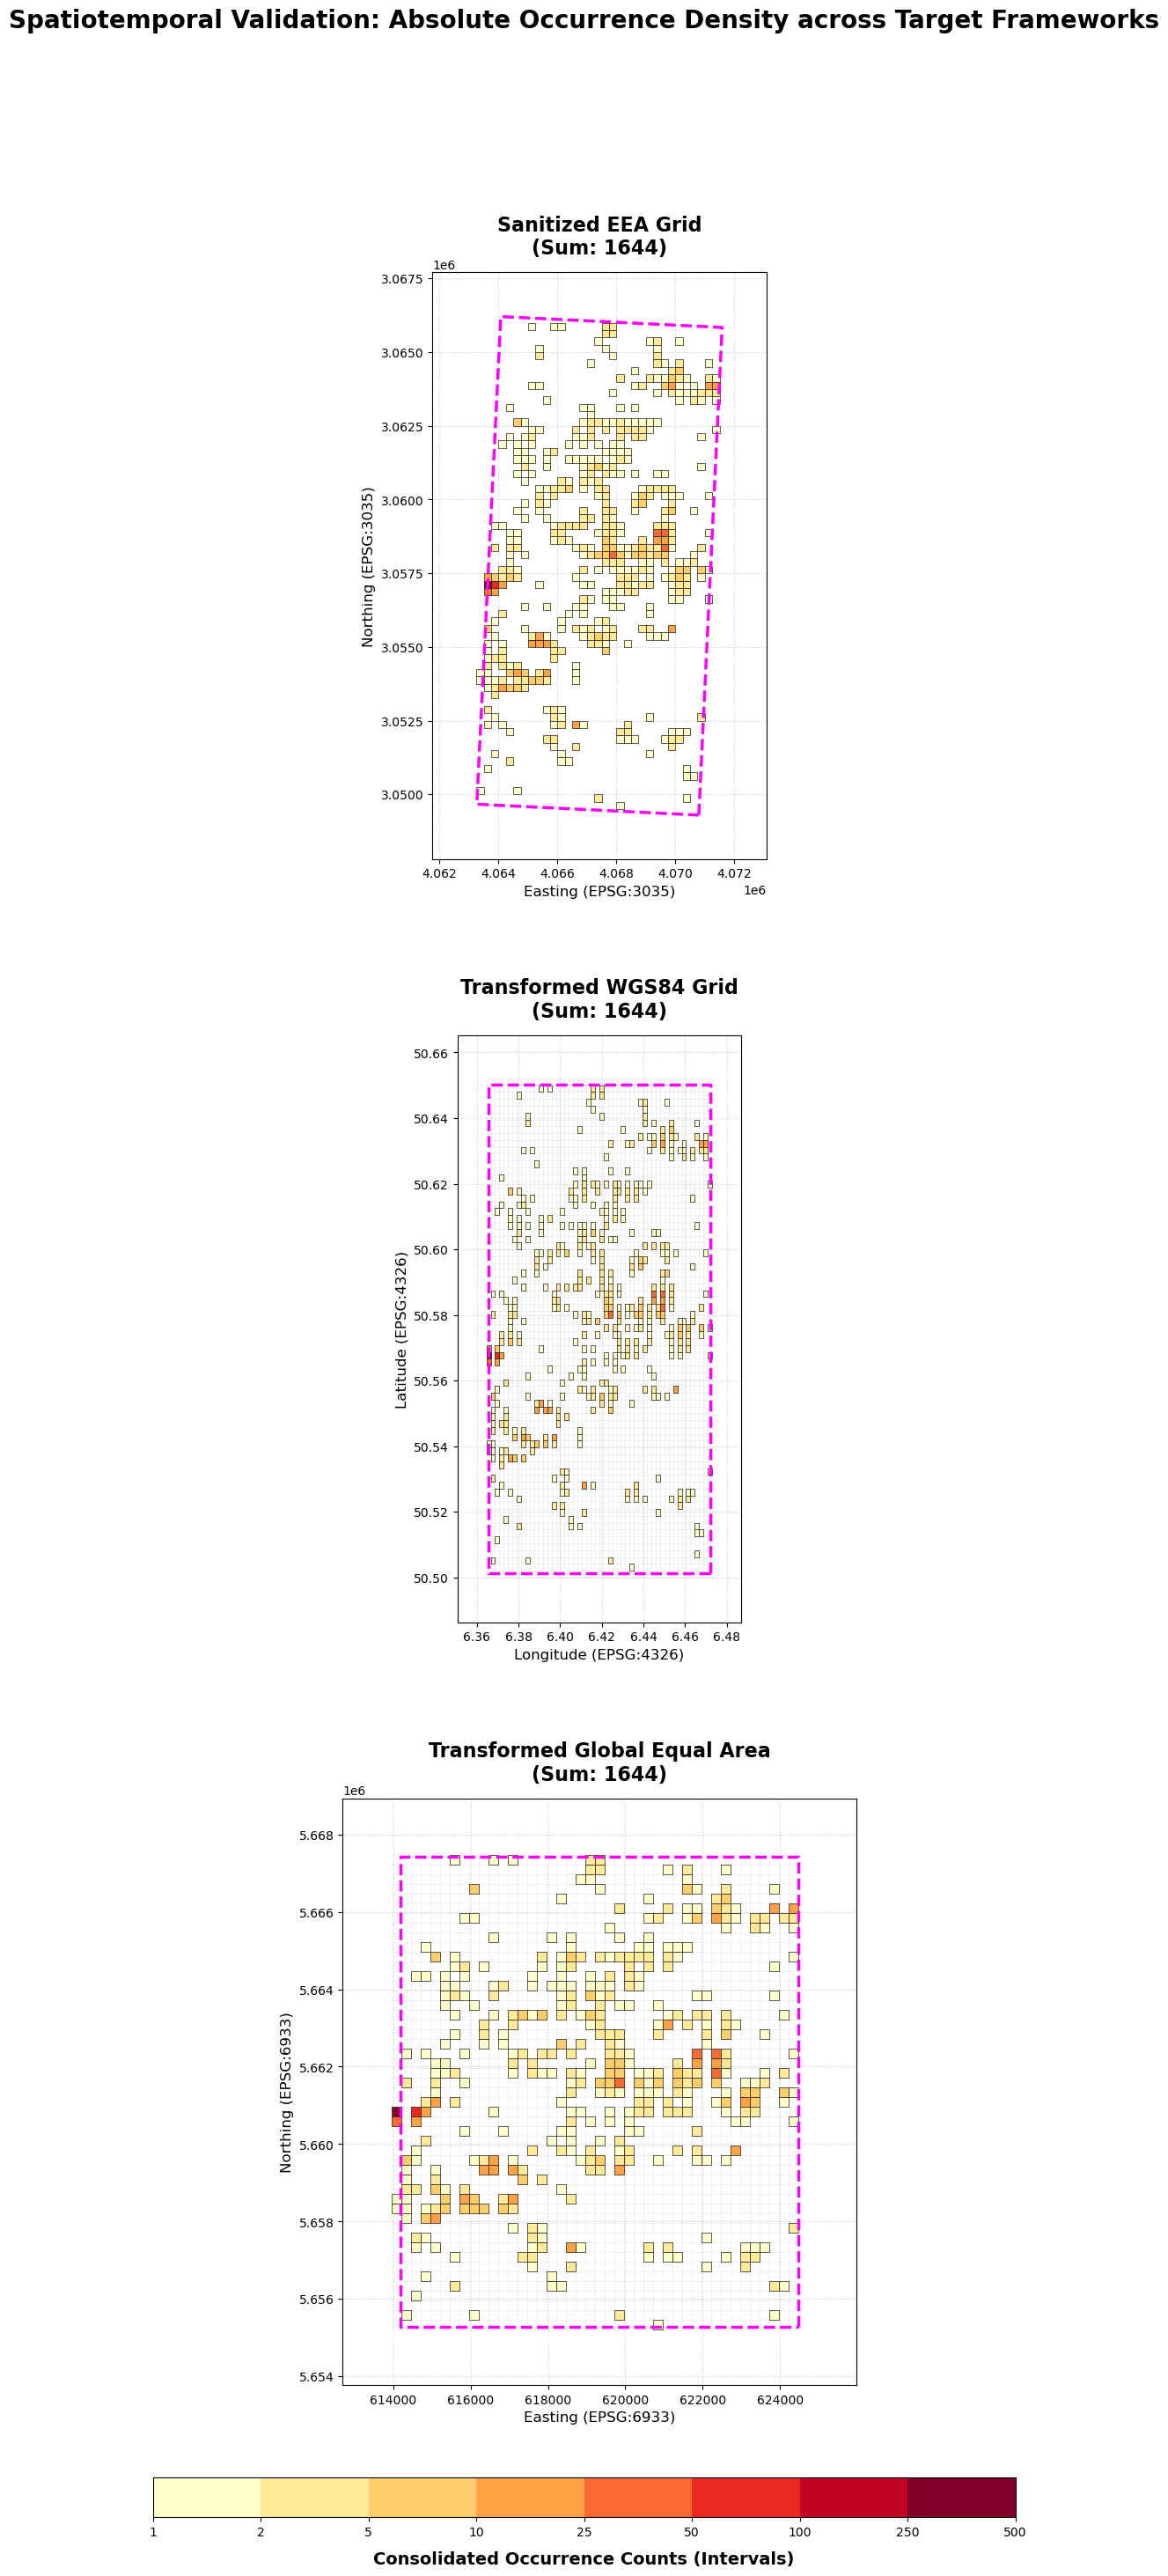

In [175]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.lines import Line2D
from shapely.geometry import box
import geopandas as gpd
import math

# Define the baseline WGS84 sampling box to superimpose on the maps
bbox = [6.365693, 50.50134, 6.472005, 50.650193]
bbox_poly = box(*bbox)
bbox_base_gdf = gpd.GeoDataFrame(geometry=[bbox_poly], crs="EPSG:4326")

# Find the absolute maximum count value across all frames
global_max_val = max(
    eea_total_gdf["occurrences"].max(),
    wgs84_total_gdf["occurrences"].max(),
    gea_total_gdf["occurrences"].max()
)

# 1. Define Discrete Intervals (Bins) for the Colorbar
upper_bound = max(500, math.ceil(global_max_val))
boundaries = [1, 2, 5, 10, 25, 50, 100, 250, upper_bound]

# 2. Create a discretized colormap and normalization object
cmap = plt.get_cmap("YlOrRd", len(boundaries) - 1)
norm = colors.BoundaryNorm(boundaries, cmap.N)

# Set up a tall 3x1 subplot layout for maximum plot size
# Increasing the height dramatically gives each plot plenty of room
fig, axes = plt.subplots(3, 1, figsize=(14, 30))

# Configuration array for uniform loop plotting
plot_configs = [
    {
        "ax": axes[0],
        "gdf": eea_total_gdf,
        "title": f"Sanitized EEA Grid\n(Sum: {eea_total_gdf['occurrences'].sum()})",
        "xlabel": "Easting (EPSG:3035)",
        "ylabel": "Northing (EPSG:3035)",
        "bbox": bbox_base_gdf.to_crs("EPSG:3035"),
        "pad": 1500
    },
    {
        "ax": axes[1],
        "gdf": wgs84_total_gdf,
        "title": f"Transformed WGS84 Grid\n(Sum: {wgs84_total_gdf['occurrences'].sum()})",
        "xlabel": "Longitude (EPSG:4326)",
        "ylabel": "Latitude (EPSG:4326)",
        "bbox": bbox_base_gdf,
        "pad": 0.015
    },
    {
        "ax": axes[2],
        "gdf": gea_total_gdf,
        "title": f"Transformed Global Equal Area\n(Sum: {gea_total_gdf['occurrences'].sum()})",
        "xlabel": "Easting (EPSG:6933)",
        "ylabel": "Northing (EPSG:6933)",
        "bbox": bbox_base_gdf.to_crs("EPSG:6933"),
        "pad": 1500
    }
]

for config in plot_configs:
    ax = config["ax"]
    dataframe = config["gdf"]
    target_bbox = config["bbox"]
    
    zeros = dataframe[dataframe["occurrences"] == 0]
    active_cells = dataframe[dataframe["occurrences"] > 0]
    
    # Draw empty background cells as fine, faint gray borders
    zeros.plot(ax=ax, facecolor="none", edgecolor="#EDEDED", linewidth=0.4)
    
    # Plot active cells using the shared discrete colormap
    if not active_cells.empty:
        active_cells.plot(
            ax=ax,
            column="occurrences",
            cmap=cmap,
            norm=norm,
            linewidth=0.5,
            edgecolor="#1A1A1A",
            legend=False
        )
        
    # Superimpose the strict intended sampling bounding box footprint
    target_bbox.plot(ax=ax, facecolor="none", edgecolor="magenta", linewidth=2.5, linestyle="--", zorder=5)
    
    # Crop the map view tightly around the target footprint
    b = target_bbox.total_bounds
    p = config["pad"]
    ax.set_xlim(b[0] - p, b[2] + p)
    ax.set_ylim(b[1] - p, b[3] + p)
    
    # Aesthetics
    ax.set_title(config["title"], fontsize=16, fontweight="bold", pad=15)
    ax.set_xlabel(config["xlabel"], fontsize=12)
    ax.set_ylabel(config["ylabel"], fontsize=12)
    ax.grid(True, linestyle=":", alpha=0.4, color="gray")

# 3. Add the Shared Global Colorbar
# Adjust bottom spacing to make room for the horizontal colorbar
plt.subplots_adjust(bottom=0.08, hspace=0.3) 
cbar_ax = fig.add_axes([0.15, 0.03, 0.7, 0.015]) # [left, bottom, width, height]

# Create a scalar mappable linking the cmap and norm for the colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 

cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal", spacing="uniform")
cbar.set_label("Consolidated Occurrence Counts (Intervals)", fontsize=14, fontweight="bold", labelpad=10)
cbar.set_ticks(boundaries)
cbar.set_ticklabels([str(b) for b in boundaries])

# Global Title
fig.suptitle(
    "Spatiotemporal Validation: Absolute Occurrence Density across Target Frameworks", 
    fontsize=20, 
    fontweight="bold", 
    y=0.98
)

plt.show()

In [169]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import ot  # Python Optimal Transport (pip install POT)

def compute_spatial_fidelity(
    gdf_original: gpd.GeoDataFrame, 
    gdf_target: gpd.GeoDataFrame, 
    value_col: str = 'occurrences',
    group_cols: list = ['scientificname', 'year', 'month'],
    shared_crs: str = "EPSG:3035"
) -> pd.DataFrame:
    """
    Computes Center of Mass shift and Wasserstein (Earth Mover's) Distance 
    between two GeoDataFrames, stratified by taxonomy and time.
    """
    # 1. Ensure both dataframes are in a shared metric projection (meters)
    orig_proj = gdf_original.to_crs(shared_crs).copy()
    targ_proj = gdf_target.to_crs(shared_crs).copy()
    
    # Reset index if the group columns are currently trapped in the index
    if orig_proj.index.name in group_cols or orig_proj.index.names[0] in group_cols:
        orig_proj = orig_proj.reset_index()
    if targ_proj.index.name in group_cols or targ_proj.index.names[0] in group_cols:
        targ_proj = targ_proj.reset_index()
        
    # Extract Centroids
    orig_proj['cx'] = orig_proj.geometry.centroid.x
    orig_proj['cy'] = orig_proj.geometry.centroid.y
    targ_proj['cx'] = targ_proj.geometry.centroid.x
    targ_proj['cy'] = targ_proj.geometry.centroid.y
    
    results = []
    
    # 2. Iterate through each unique Stratum (Species + Year + Month)
    groups = orig_proj.groupby(group_cols)
    
    for group_keys, orig_group in groups:
        # Build dictionary for dynamic group keys unpacking
        group_dict = dict(zip(group_cols, group_keys if isinstance(group_keys, tuple) else [group_keys]))
        
        # Find matching group in target dataset
        query_mask = np.ones(len(targ_proj), dtype=bool)
        for col, val in group_dict.items():
            query_mask &= (targ_proj[col] == val)
            
        targ_group = targ_proj[query_mask]
        
        # Skip if target group is missing or empty
        if targ_group.empty or orig_group[value_col].sum() == 0 or targ_group[value_col].sum() == 0:
            continue
            
        # ==========================================
        # METRIC 1: Center of Mass (Weighted Mean)
        # ==========================================
        w_orig = orig_group[value_col].values
        w_targ = targ_group[value_col].values
        
        orig_com_x = np.average(orig_group['cx'].values, weights=w_orig)
        orig_com_y = np.average(orig_group['cy'].values, weights=w_orig)
        
        targ_com_x = np.average(targ_group['cx'].values, weights=w_targ)
        targ_com_y = np.average(targ_group['cy'].values, weights=w_targ)
        
        # Euclidean distance between the two Centers of Mass (in meters)
        com_shift_meters = np.sqrt((targ_com_x - orig_com_x)**2 + (targ_com_y - orig_com_y)**2)
        
        # ==========================================
        # METRIC 2: Wasserstein Metric (EMD)
        # ==========================================
        coords_orig = np.column_stack((orig_group['cx'], orig_group['cy']))
        coords_targ = np.column_stack((targ_group['cx'], targ_group['cy']))
        
        # Normalize weights so they sum to 1 (Required for Optimal Transport probabilities)
        p_orig = w_orig / w_orig.sum()
        p_targ = w_targ / w_targ.sum()
        
        # Calculate the Euclidean distance cost matrix between all points
        cost_matrix = ot.dist(coords_orig, coords_targ, metric='euclidean')
        
        # Compute exact Earth Mover's Distance
        emd_meters = ot.emd2(p_orig, p_targ, cost_matrix)
        
        # Store results
        results.append({
            **group_dict,
            'occurrences_orig': w_orig.sum(),
            'occurrences_targ': w_targ.sum(),
            'com_shift_meters': round(com_shift_meters, 2),
            'wasserstein_meters': round(emd_meters, 2)
        })
        
    return pd.DataFrame(results)

In [187]:
import pandas as pd
import geopandas as gpd
import xarray as xr
import xvec

# --- Step 1: Extract and Format the Year-Month Coordinate ---
# We combine your 'year' and 'month' columns into a standard YYYY-MM string
wgs84_kdtree_gdf['year_month'] = (
    wgs84_kdtree_gdf['year'].astype(str) + '-' + 
    wgs84_kdtree_gdf['month'].astype(str).str.zfill(2)
)

# --- Step 2: Aggregate to enforce clean MultiIndexing ---
# Sum up 'occurrences' across identical scientific names, time slices, and geometries
# This collapses any accidental duplicates into a unique Cartesian grid intersection
aggregated_df = (
    wgs84_kdtree_gdf.groupby(['scientificname', 'year_month', 'geometry'], as_index=False)
    ['occurrences'].sum()
)

# --- Step 3: Shift Target Dimensions into the Index ---
# Prepare the dataframe for the multidimensional xarray pivot
pivot_ready = aggregated_df.set_index(['scientificname', 'year_month', 'geometry'])

# --- Step 4: Pivot Tabular Data into an N-Dimensional Cube ---
# This automatically spins out scientificname, year_month, and geometry into coordinates
vector_cube = pivot_ready.to_xarray()

# --- Step 5: Activate the xvec Geometry Index ---
# Pass the original CRS of your GeoDataFrame to ensure perfect spatial mapping
vector_cube = vector_cube.xvec.set_geom_indexes("geometry", crs=wgs84_kdtree_gdf.crs)

# Display the resulting data structure
print(vector_cube)

ImportError: cannot import name 'AlignmentError' from 'xarray' (c:\Users\niels\anaconda3\envs\BmC\Lib\site-packages\xarray\__init__.py)

C:\Users\niels\AppData\Local\Temp\ipykernel_33208\2562397856.py:44: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  zeros.plot(


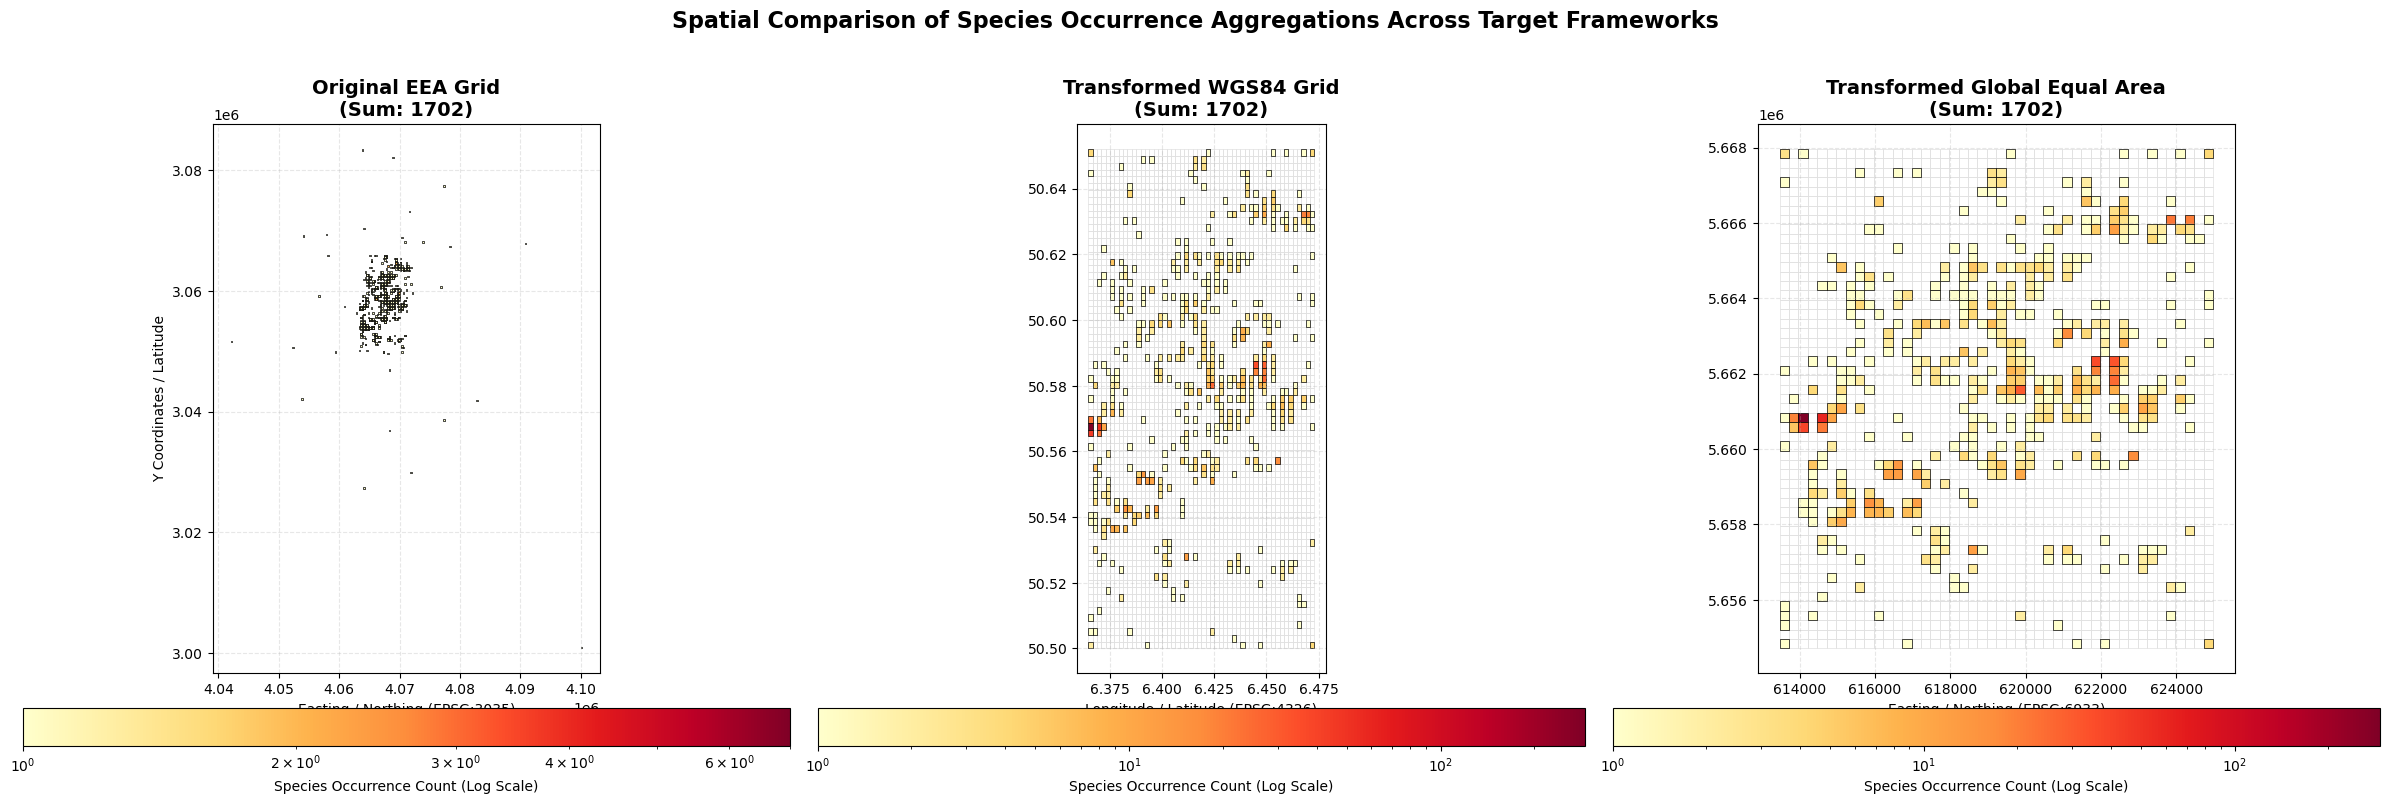

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import geopandas as gpd

# Assuming 'gdf' is your original source data, 
# and 'wgs84_mapped_gdf' & 'gea_mapped_gdf' are your outputs from the KDTree function.

# 1. Set up a 1x3 subplot figure to compare the distributions
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Configuration dictionary for clear looping
map_configs = [
    {
        "ax": axes[0],
        "gdf": gdf,
        "title": f"Original EEA Grid\n(Sum: {gdf['occurrences'].sum()})",
        "label": "Easting / Northing (EPSG:3035)"
    },
    {
        "ax": axes[1],
        "gdf": wgs84_mapped_gdf,
        "title": f"Transformed WGS84 Grid\n(Sum: {wgs84_mapped_gdf['occurrences'].sum()})",
        "label": "Longitude / Latitude (EPSG:4326)"
    },
    {
        "ax": axes[2],
        "gdf": gea_mapped_gdf,
        "title": f"Transformed Global Equal Area\n(Sum: {gea_mapped_gdf['occurrences'].sum()})",
        "label": "Easting / Northing (EPSG:6933)"
    }
]

# 2. Loop through and plot each GeoDataFrame
for config in map_configs:
    ax = config["ax"]
    dataframe = config["gdf"]
    
    # We create a mask to separate zero cells from actual observations
    # This prevents '0' from skewing our colormap
    zeros = dataframe[dataframe['occurrences'] == 0]
    observations = dataframe[dataframe['occurrences'] > 0]
    
    # Plot the background grid cells with 0 occurrences as light gray lines
    zeros.plot(
        ax=ax, 
        facecolor='none', 
        edgecolor='#E0E0E0', 
        linewidth=0.5
    )
    
    # Plot the actual data hotspots using a Logarithmic scale 
    # This ensures values like 1-5 are still visible alongside values like 293
    if not observations.empty:
        observations.plot(
            ax=ax,
            column='occurrences',
            cmap='YlOrRd',
            linewidth=0.5,
            edgecolor='black',
            legend=True,
            norm=LogNorm(vmin=1, vmax=dataframe['occurrences'].max()),
            legend_kwds={'label': "Species Occurrence Count (Log Scale)", 'orientation': "horizontal", 'pad': 0.05}
        )
        
    # Formatting details
    ax.set_title(config["title"], fontsize=14, fontweight='bold')
    ax.set_xlabel(config["label"], fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.3)

# 3. Apply global titles and layout cleanups
axes[0].set_ylabel("Y Coordinates / Latitude", fontsize=10)
fig.suptitle("Spatial Comparison of Species Occurrence Aggregations Across Target Frameworks", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# Display the map
plt.show()

In [181]:
import pandas as pd
import numpy as np

# Assuming wgs84_kdtree_gdf, gea_kdtree_gdf, wgs84_intersect_gdf, and gea_intersect_gdf 
# were generated successfully in the previous step.

# 1. Define a dictionary of the transformed DataFrames we want to evaluate
transformed_datasets = {
    "WGS84 (KDTree Strategy)": wgs84_kdtree_gdf,
    "GEA (KDTree Strategy)": gea_kdtree_gdf,
    "WGS84 (Intersect Strategy)": wgs84_intersect_gdf,
    "GEA (Intersect Strategy)": gea_intersect_gdf
}

summary_metrics = []

# 2. Iterate through each dataset and compute the fidelity metrics
for name, target_gdf in transformed_datasets.items():
    print(f"⚙️ Computing metrics for {name}...")
    
    # Run the Wasserstein and Center of Mass math
    validation_df = compute_spatial_fidelity(
        gdf_original=gdf_sanitized,
        gdf_target=target_gdf, 
        value_col='occurrences',
        group_cols=['scientificname', 'year', 'month'],
        shared_crs="EPSG:3035"
    )
    
    # Extract the global means across all stratified species/time groups
    mean_com_shift = validation_df['com_shift_meters'].mean()
    mean_wasserstein = validation_df['wasserstein_meters'].mean()
    
    # Store the results
    summary_metrics.append({
        "Target Framework": name,
        "Mean CoM Shift (meters)": round(mean_com_shift, 2),
        "Mean Wasserstein Dist (meters)": round(mean_wasserstein, 2)
    })

# 3. Format and display the final comparison table
summary_df = pd.DataFrame(summary_metrics)

print("\n=========================================================")
print("🌍 SPATIAL FIDELITY VALIDATION RESULTS")
print("=========================================================")
print(summary_df.to_string(index=False))
print("=========================================================")

⚙️ Computing metrics for WGS84 (KDTree Strategy)...
⚙️ Computing metrics for GEA (KDTree Strategy)...
⚙️ Computing metrics for WGS84 (Intersect Strategy)...
⚙️ Computing metrics for GEA (Intersect Strategy)...

🌍 SPATIAL FIDELITY VALIDATION RESULTS
          Target Framework  Mean CoM Shift (meters)  Mean Wasserstein Dist (meters)
   WGS84 (KDTree Strategy)                    70.46                           74.87
     GEA (KDTree Strategy)                    99.20                          107.01
WGS84 (Intersect Strategy)                    70.46                           74.87
  GEA (Intersect Strategy)                    99.23                          107.01


In [177]:
wgs84_total_gdf

,grid_id,geometry,occurrences
0,0,"POLYGON ((6.36667 50.65, 6.36667 50.65208, 6.3...",0
1,1,"POLYGON ((6.36875 50.65, 6.36875 50.65208, 6.3...",0
2,2,"POLYGON ((6.37083 50.65, 6.37083 50.65208, 6.3...",0
3,3,"POLYGON ((6.37292 50.65, 6.37292 50.65208, 6.3...",0
4,4,"POLYGON ((6.375 50.65, 6.375 50.65208, 6.37292...",0
...,...,...,...
3791,3791,"POLYGON ((6.46458 50.5, 6.46458 50.50208, 6.46...",0
3792,3792,"POLYGON ((6.46667 50.5, 6.46667 50.50208, 6.46...",0
3793,3793,"POLYGON ((6.46875 50.5, 6.46875 50.50208, 6.46...",0
3794,3794,"POLYGON ((6.47083 50.5, 6.47083 50.50208, 6.46...",0


In [ ]:
import numpy as np

def check_grid_alignment(gdf, raster, resolution=250):
    """
    Checks if a GeoDataFrame's polygons align perfectly with a raster's grid.
    """
    print("--- Alignment Diagnostic Report ---")
    
    # 1. Check Polygon Drift
    # Extract the lower-left coordinates (minx, miny) for all polygons
    bounds = gdf.bounds
    poly_minx = bounds['minx'].values
    poly_miny = bounds['miny'].values
    
    # Calculate how far off the polygons are from a pure 250m interval
    x_drift = np.abs(poly_minx % resolution)
    y_drift = np.abs(poly_miny % resolution)
    
    # Account for modulo wrap-around (e.g., a drift of 249.999 is actually a drift of -0.001)
    x_drift = np.minimum(x_drift, resolution - x_drift)
    y_drift = np.minimum(y_drift, resolution - y_drift)
    
    max_poly_x_drift = np.max(x_drift)
    max_poly_y_drift = np.max(y_drift)
    
    if np.isclose(max_poly_x_drift, 0, atol=1e-6) and np.isclose(max_poly_y_drift, 0, atol=1e-6):
        print("✅ Polygons: Perfectly snapped to the 250m grid (No drift detected).")
    else:
        print(f"❌ Polygons: Drift detected! Max X drift: {max_poly_x_drift}m, Max Y drift: {max_poly_y_drift}m")

    # 2. Check Raster Grid Drift
    # Extract the first x and y coordinates from the raster
    rx = raster.x.values[0]
    ry = raster.y.values[0]
    
    # Determine if raster coords represent edges (remainder 0) or pixel centers (remainder 125)
    rx_rem = rx % resolution
    
    if np.isclose(rx_rem, 0, atol=1e-6):
        print("✅ Raster: Coordinates represent pixel EDGES and are aligned.")
        raster_is_aligned = True
    elif np.isclose(rx_rem, resolution / 2, atol=1e-6):
        print("✅ Raster: Coordinates represent pixel CENTERS and are aligned.")
        raster_is_aligned = True
    else:
        print(f"❌ Raster: Sub-pixel drift detected in the template raster! Offset: {rx_rem}m")
        raster_is_aligned = False
        
    # 3. Final Conclusion
    if np.isclose(max_poly_x_drift, 0, atol=1e-6) and raster_is_aligned:
        print("\n🏆 CONCLUSION: 1-to-1 Match Confirmed. No drift between datasets.")
    else:
        print("\n⚠️ CONCLUSION: Misalignment detected. Do not proceed with rasterization without fixing the grid origins.")

# Run the diagnostic (assuming your variables are named 'gdf' and 'template_raster')
check_grid_alignment(gdf, template_raster, resolution=250)